# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

import warnings
warnings.filterwarnings("ignore")

### Observation

🟢 Required libraries for model training, evaluation, visualization, and serialization were imported successfully.

🟢 These libraries will support the complete machine learning workflow from training to deployment.

# Loading Processed Datasets

In [2]:
train_df = pd.read_csv(
    "processed_train.csv"
)

test_df = pd.read_csv(
    "processed_test.csv"
)

print("Train Dataset Shape :", train_df.shape)

print("Test Dataset Shape :", test_df.shape)

Train Dataset Shape : (1017209, 24)
Test Dataset Shape : (41088, 23)


### Observation

🟢 The processed training and testing datasets were loaded successfully.

🟢 These datasets contain cleaned, encoded, and feature-engineered variables ready for machine learning model development.

# Viewing Dataset Sample

In [3]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,Quarter,IsWeekend
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,1,13.0,2010.0,1,1.502077,0.346724,1.740766,0.501484,0.652353,0
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,1,14.0,2011.0,1,1.502077,0.346724,1.740766,0.501484,0.652353,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0


### Observation

🟢 The dataset appears properly structured and contains the engineered features created during preprocessing.

🟢 The data is ready for feature-target separation and model training.

# Feature and Target Separation

In [4]:
X = train_df.drop(
    ["Sales", "Date", "Customers"],
    axis=1
)

y = train_df["Sales"]

print("Feature Dataset Shape :", X.shape)

print("Target Dataset Shape :", y.shape)

Feature Dataset Shape : (1017209, 21)
Target Dataset Shape : (1017209,)


### Observation

🟢 The target variable Sales was separated successfully.

🟢 Customers was excluded from model training as per project requirements.

🟢 The resulting feature matrix and target vector are ready for train-test splitting.

# Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Feature Shape :", X_train.shape)

print("Testing Feature Shape :", X_test.shape)

print("Training Target Shape :", y_train.shape)

print("Testing Target Shape :", y_test.shape)

Training Feature Shape : (813767, 21)
Testing Feature Shape : (203442, 21)
Training Target Shape : (813767,)
Testing Target Shape : (203442,)


### Observation

🟢 The dataset was successfully divided into training and testing subsets.

🟢 80% of the data will be used for model training and 20% for evaluation.

🟢 This split helps measure the model's ability to generalize to unseen data.

# Random Forest Model Initialization

In [6]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Model Initialized Successfully")

Random Forest Model Initialized Successfully


### Observation

🟢 The Random Forest Regressor model was initialized successfully.

🟢 The model will use 100 decision trees to learn sales patterns from the training data.

🟢 Parallel processing has been enabled to improve training efficiency.

# Model Training

In [7]:
random_forest.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


### Observation

🟢 The Random Forest model was trained successfully using the training dataset.

🟢 During training, the model learned patterns and relationships between store characteristics and sales.

🟢 The trained model is now ready to generate predictions on unseen data.

# Model Prediction

In [8]:
y_pred = random_forest.predict(
    X_test
)

print("Predictions Generated Successfully")

Predictions Generated Successfully


### Observation

🟢 The trained Random Forest model successfully generated predictions on unseen testing data.

🟢 These predictions will be used to assess the forecasting accuracy of the model.

🟢 Comparing actual and predicted sales values helps evaluate model performance.

# Model Evaluation

In [9]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Mean Absolute Error :", mae)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 486.54150077171874
Root Mean Squared Error : 835.8051136278705
R2 Score : 0.9527635529054624


### Observation

🟢 The Random Forest model achieved strong predictive performance on the testing dataset.

🟢 The Mean Absolute Error (MAE) indicates that the average prediction error is relatively low compared to the overall sales values.

🟢 The Root Mean Squared Error (RMSE) shows that large prediction errors are limited.

🟢 The model achieved an R² Score of approximately 95%, indicating that it explains most of the variation in sales data.

🟢 Overall, the model demonstrates excellent forecasting capability and generalization performance.

# Actual vs Predicted Sales

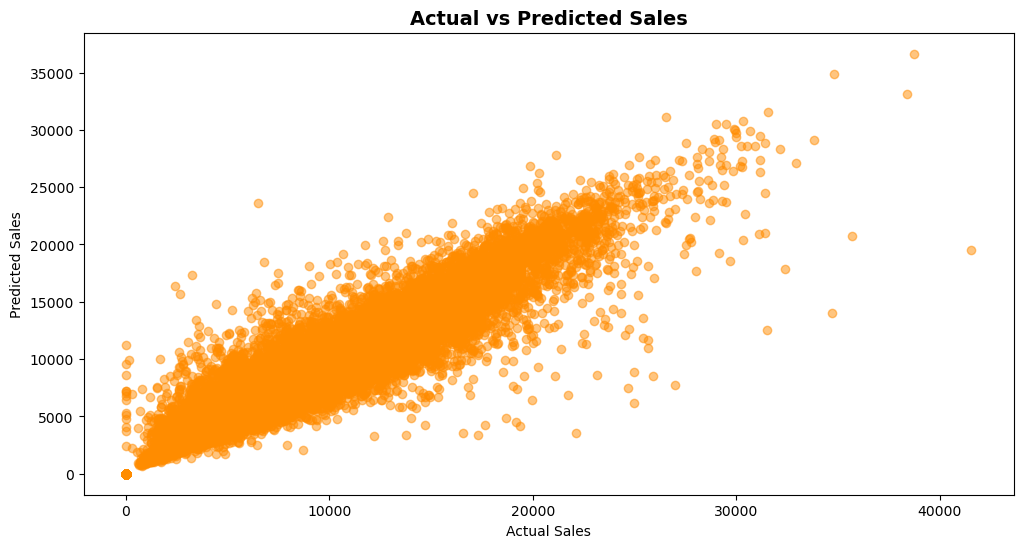

In [10]:
plt.figure(figsize=(12,6))

plt.scatter(
    y_test,
    y_pred,
    color="darkorange",
    alpha=0.5
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Observation

🟢 The predicted sales values closely follow the actual sales values.

🟢 Most observations are concentrated around the ideal prediction region, indicating good model accuracy.

🟢 The model successfully captures underlying sales patterns across stores.

🟢 A small number of deviations are present, which is expected in real-world forecasting problems.

# Feature Importance Analysis

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Open,0.459827
8,CompetitionDistance,0.107820
0,Store,0.095231
3,Promo,0.073461
10,CompetitionOpenSinceYear,0.040780
9,CompetitionOpenSinceMonth,0.035984
17,Day,0.029009
16,Month,0.023471
18,Weekday,0.020632
6,StoreType,0.019009


### Observation

🟢 Feature importance analysis identifies the most influential variables affecting store sales.

🟢 The top-ranked features contribute significantly to the model's decision-making process.

🟢 Understanding feature importance helps interpret model behavior and business drivers of sales performance.

🟢 These insights can support data-driven business strategies and forecasting improvements.

# Visualization

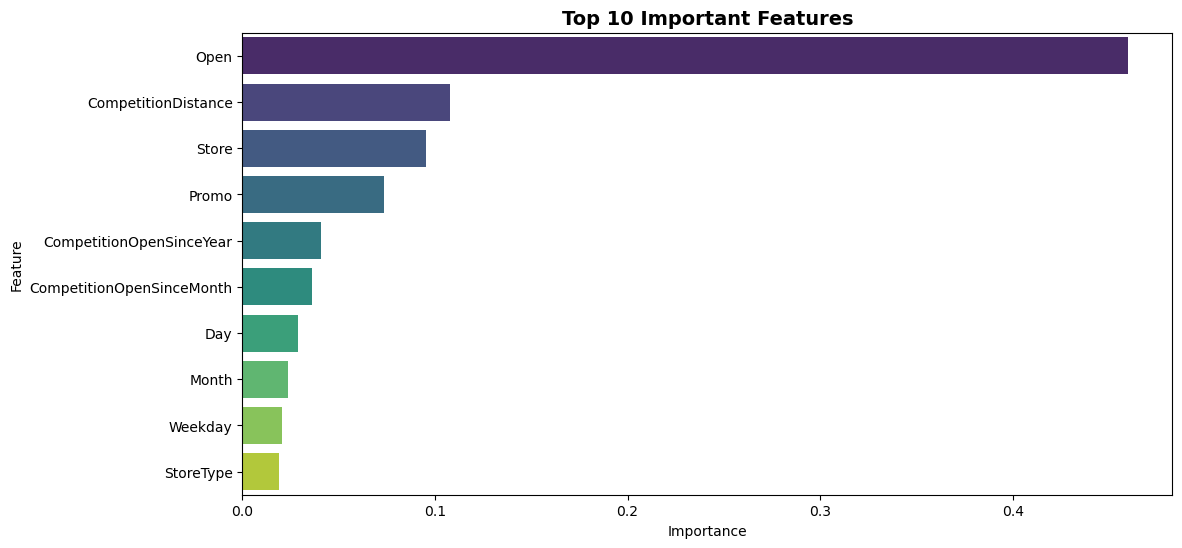

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10),
    palette="viridis"
)

plt.title(
    "Top 10 Important Features",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Observation

🟢 The visualization highlights the top 10 most important features influencing sales predictions.

🟢 Features with higher importance scores have a stronger impact on the model's forecasting decisions.

🟢 Understanding feature importance improves model interpretability and helps identify the primary business factors affecting sales performance.

🟢 These insights can support strategic decision-making related to promotions, store operations, and sales forecasting.

# Residual Analysis

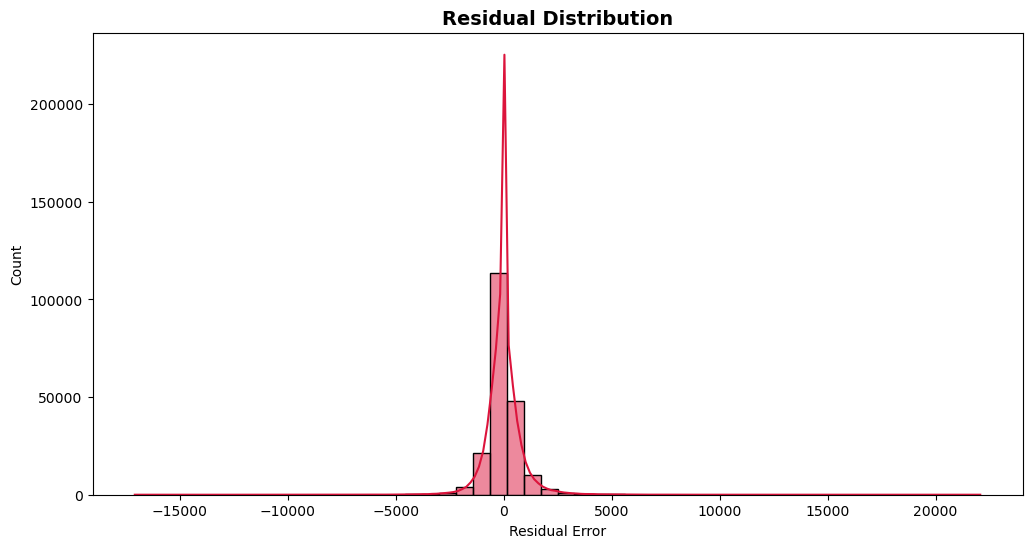

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(12,6))

sns.histplot(
    residuals,
    bins=50,
    kde=True,
    color="crimson"
)

plt.title(
    "Residual Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Residual Error")

plt.show()

### Observation

🟢 Residuals are distributed around zero, indicating that prediction errors are generally balanced.

🟢 Most prediction errors fall within a relatively small range.

🟢 The residual distribution suggests that the model does not exhibit significant systematic bias.

🟢 Overall, the residual analysis confirms that the model provides reliable sales forecasts.

# Model Serialization

In [14]:
with open(
    "random_forest_model.pkl",
    "wb"
) as file:
    
    pickle.dump(
        random_forest,
        file
    )

print("Model Saved Successfully")

Model Saved Successfully


### Observation

🟢 The trained Random Forest model was successfully saved.

🟢 Model serialization enables future predictions without repeating the training process.

🟢 The saved model can be deployed or loaded for inference in production environments.

# Loading Saved Model

In [15]:
with open(
    "random_forest_model.pkl",
    "rb"
) as file:
    
    loaded_model = pickle.load(
        file
    )

print("Model Loaded Successfully")

Model Loaded Successfully


### Observation

🟢 The serialized model was loaded successfully.

🟢 The loaded model is identical to the trained model and ready for prediction tasks.

# Predicting Sales on Test Dataset

In [17]:
test_features = test_df.drop(
    ["Date", "Id"],
    axis=1
)

test_features = test_features.reindex(
    columns=X_train.columns,
    fill_value=0
)

test_predictions = loaded_model.predict(
    test_features
)

print("Predictions Generated Successfully")

Predictions Generated Successfully


### Observation

🟢 Sales predictions were successfully generated for the test dataset.

🟢 The model can now forecast sales for unseen store records.

🟢 These predictions can be used for business planning and decision-making.

# Creating Prediction File

In [18]:
prediction_df = pd.DataFrame({
    "Predicted_Sales": test_predictions
})

prediction_df.head()

,Predicted_Sales
0,4349.66
1,7418.85
2,9282.59
3,8205.16
4,7650.06


In [19]:
prediction_df.to_csv(
    "sales_predictions.csv",
    index=False
)

print(
    "Prediction File Saved Successfully"
)

Prediction File Saved Successfully


### Observation

🟢 Predicted sales values were successfully exported to a CSV file.

🟢 The generated file can be shared, analyzed, or integrated into business reporting workflows.